In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ds = pd.read_csv('Walmart.csv')
ds.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
ds.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [5]:
ds.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
ds.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [7]:
ds.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [8]:
ds.duplicated().sum()

0

In [9]:
ds['Date'] = pd.to_datetime(ds['Date'], format='%d-%m-%Y')
ds.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
ds.value_counts()

Store  Date        Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  CPI         Unemployment
1      2010-02-05  1643690.90    0             42.31        2.572       211.096358  8.106           1
30     2012-10-05  446751.45     0             70.28        3.617       222.815930  6.170           1
31     2010-03-19  1332261.01    0             54.68        2.720       210.873332  8.324           1
       2010-03-12  1366193.35    0             57.10        2.667       211.037551  8.324           1
       2010-03-05  1384870.51    0             48.61        2.625       211.006754  8.324           1
                                                                                                   ..
15     2012-10-12  551799.63     0             49.12        4.186       138.911700  7.992           1
       2012-10-05  573498.64     0             59.57        4.151       138.825600  7.992           1
       2012-09-28  553901.97     0             57.13        4.158       138.739500  8.1

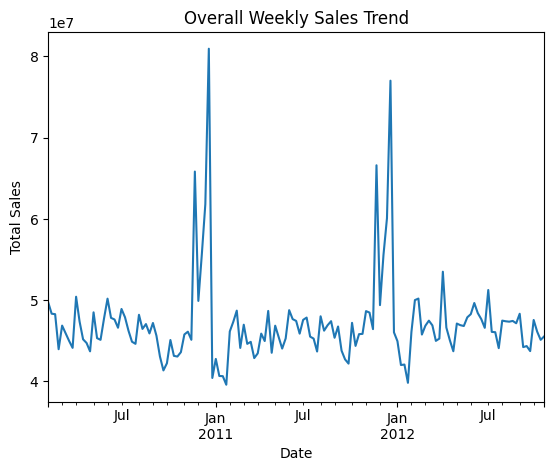

In [11]:
plt.figure()
ds.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Overall Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

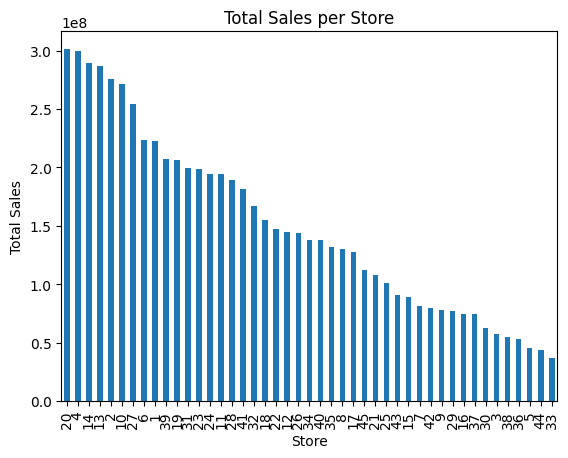

In [12]:
store_sales = ds.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
plt.figure()
store_sales.plot(kind='bar')
plt.title("Total Sales per Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

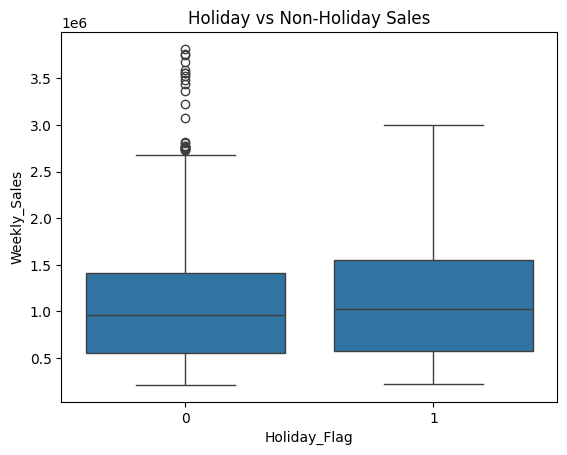

In [13]:
plt.figure()
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=ds)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

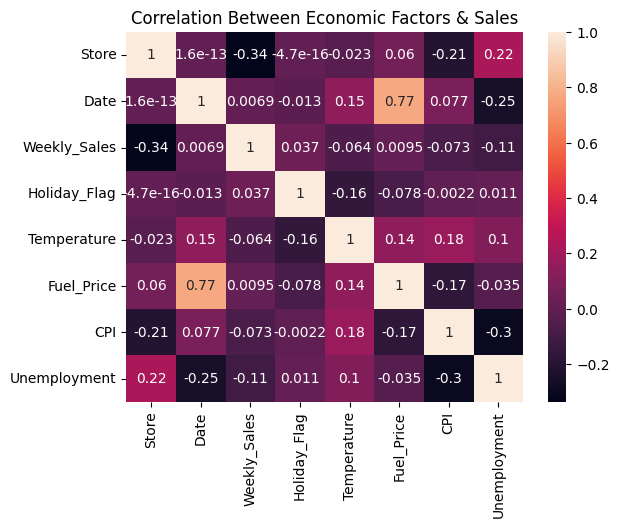

In [14]:
plt.figure()
sns.heatmap(ds.corr(), annot=True)
plt.title("Correlation Between Economic Factors & Sales")
plt.show()